# NYC Hunger Games — Project Notebook

This notebook documents the data, preprocessing, exploratory analysis, and the decisions made while building the interactive site and maps for the NYC Survival Score final project. It reproduces the main plots used in the website and answers the instructor's questions.

## What is your dataset?

We combine cleaned extracts of several NYC Open Data sources. The cleaned CSVs are in `data/processed/` and include:

- `drinking_fountains_cleaned.csv` — outdoor park fountains
- `public_toilets_cleaned.csv` — public toilet locations
- `drop_in_centers_cleaned.csv` — drop-in centers offering services
- `link_nyc_cleaned.csv` — LinkNYC kiosks (Wi‑Fi, charging)
- `shelter_repair_cleaned.csv` — shelter repair/violation records
- `drug_crime_cleaned.csv` — drug-related incident reports

We also use a grid of evaluation points: `website/assets/data/survival_grid.csv`, which is the set of candidate locations used to compute the Survival Score.

In [7]:
import pandas as pd
import requests
import os

# Create directories if they don't exist
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

DATASETS = {
    "drop_in_centers": "bmxf-3rd4",
    "public_toilets": "7z3a-ched",
    "drinking_fountains": "qnv7-p7a2",
    "shelter_repair": "dvaj-b7yx",
    "link_nyc": "s4kf-3yrf",
    "rhy_census": "5rw7-99k7",
    "drug_crime": "v35q-aj2k"
}

def download_nyc_data(dataset_id, name):
    print(f"Downloading {name} ({dataset_id})...")
    url = f"https://data.cityofnewyork.us/resource/{dataset_id}.csv?$limit=1000000"
    response = requests.get(url)
    if response.status_code == 200:
        with open(f"../data/raw/{name}.csv", "wb") as f:
            f.write(response.content)
        print(f"Success: {name}.csv saved.")
    else:
        print(f"Error downloading {name}: {response.status_code}")

for name, ds_id in DATASETS.items():
    download_nyc_data(ds_id, name)

Success: drop_in_centers.csv saved.
Success: public_toilets.csv saved.
Success: drinking_fountains.csv saved.
Success: shelter_repair.csv saved.
Success: link_nyc.csv saved.
Success: rhy_census.csv saved.
Success: drug_crime.csv saved.


In [9]:
import pandas as pd
import os
import re

# Paths
RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

if not os.path.exists(PROCESSED_DIR):
    os.makedirs(PROCESSED_DIR)

def extract_lat_long(geom_str):
    """Extracts lat/long from POINT (long lat) strings."""
    if pd.isna(geom_str) or not isinstance(geom_str, str):
        return None, None
    match = re.search(r'POINT \(([-\d\.]+) ([-\d\.]+)\)', geom_str)
    if match:
        return float(match.group(2)), float(match.group(1))
    return None, None

# Borough standardization mapping
BORO_MAP = {
    'M': 'Manhattan', 'B': 'Brooklyn', 'X': 'Bronx', 'Q': 'Queens', 'R': 'Staten Island',
    'BK': 'Brooklyn', 'BX': 'Bronx', 'QN': 'Queens', 'SI': 'Staten Island', 'MN': 'Manhattan',
    'RICHMOND': 'Staten Island'
}

def standardize_boro(boro):
    if pd.isna(boro) or not isinstance(boro, str):
        return boro
    boro = boro.strip()
    title_boro = boro.title()
    if title_boro in ['Manhattan', 'Brooklyn', 'Bronx', 'Queens', 'Staten Island']:
        return title_boro
    return BORO_MAP.get(boro.upper(), title_boro)

print("Setup complete.")

Setup complete.


In [10]:
def clean_spatial_dataset(filename, boro_col, lat_col=None, lon_col=None, geom_col=None, cols_to_keep=None):
    print(f"Cleaning {filename}...")
    df = pd.read_csv(os.path.join(RAW_DIR, filename))
    
    if geom_col:
        df['latitude'], df['longitude'] = zip(*df[geom_col].apply(extract_lat_long))
    elif lat_col and lon_col:
        df['latitude'] = pd.to_numeric(df[lat_col], errors='coerce')
        df['longitude'] = pd.to_numeric(df[lon_col], errors='coerce')
    
    df[boro_col] = df[boro_col].apply(standardize_boro)
    
    if cols_to_keep:
        df = df[cols_to_keep + ['latitude', 'longitude', boro_col]]
    
    # 1. DROP MISSING VALUES
    df.dropna(subset=['latitude', 'longitude'], inplace=True)
    
    # 2. SPATIAL FILTER (THE FIX): Remove (0,0) and extreme outliers
    # NYC is roughly Latitude 40.5-40.9 and Longitude -74.3 to -73.7
    df = df[
        (df['latitude'] > 40.0) & (df['latitude'] < 42.0) &
        (df['longitude'] > -75.0) & (df['longitude'] < -72.0)
    ]
    
    output_name = filename.replace('.csv', '_cleaned.csv')
    df.to_csv(os.path.join(PROCESSED_DIR, output_name), index=False)
    return len(df)


counts = {}
counts['fountains'] = clean_spatial_dataset('drinking_fountains.csv', 'borough', geom_col='the_geom', cols_to_keep=['propertyna'])
counts['toilets'] = clean_spatial_dataset('public_toilets.csv', 'boro_name', geom_col='the_geom', cols_to_keep=['site_name'])
counts['centers'] = clean_spatial_dataset('drop_in_centers.csv', 'borough', lat_col='latitude', lon_col='longitude', cols_to_keep=['center_name'])
counts['link_nyc'] = clean_spatial_dataset('link_nyc.csv', 'boro', lat_col='latitude', lon_col='longitude', cols_to_keep=['neighborhood_tabulation_area_nta'])
counts['drug_crime'] = clean_spatial_dataset('drug_crime.csv', 'boro_nm', lat_col='latitude', lon_col='longitude', cols_to_keep=['cmplnt_fr_dt', 'ofns_desc'])

for k, v in counts.items():
    print(f"{k}: {v} rows")

Cleaning drinking_fountains.csv...
Cleaning public_toilets.csv...
Cleaning drop_in_centers.csv...
Cleaning link_nyc.csv...
Cleaning drug_crime.csv...
fountains: 3849 rows
toilets: 7 rows
centers: 8 rows
link_nyc: 2255 rows
drug_crime: 490665 rows


In [11]:
print("Cleaning shelter_repair and rhy_census...")
df_shelter = pd.read_csv(os.path.join(RAW_DIR, 'shelter_repair.csv'))
df_shelter.to_csv(os.path.join(PROCESSED_DIR, 'shelter_repair_cleaned.csv'), index=False)

df_rhy = pd.read_csv(os.path.join(RAW_DIR, 'rhy_census.csv'))
df_rhy.to_csv(os.path.join(PROCESSED_DIR, 'rhy_census_cleaned.csv'), index=False)

print("Cleaning complete.")

Cleaning shelter_repair and rhy_census...
Cleaning complete.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED_DIR = '../data/processed/'

def load_processed(filename):
    return pd.read_csv(os.path.join(PROCESSED_DIR, filename))

print("Setup complete.")

Setup complete.


In [13]:
# 1. Load Data
fountains = load_processed('drinking_fountains_cleaned.csv')
centers = load_processed('drop_in_centers_cleaned.csv')
crime = load_processed('drug_crime_cleaned.csv')
link = load_processed('link_nyc_cleaned.csv')
toilets = load_processed('public_toilets_cleaned.csv')
rhy = load_processed('rhy_census_cleaned.csv')
shelter = load_processed('shelter_repair_cleaned.csv')

# 2. Apply Temporal Filtering (Last 10 Years: 2014-2024)
# Filter Crime
crime['cmplnt_fr_dt'] = pd.to_datetime(crime['cmplnt_fr_dt'], errors='coerce')
crime = crime[crime['cmplnt_fr_dt'].dt.year >= 2014]

# Filter RHY Census (if date exists)
if 'date' in rhy.columns:
    rhy['date'] = pd.to_datetime(rhy['date'], errors='coerce')
    rhy = rhy[rhy['date'].dt.year >= 2014]

print(f"Data Loaded and Filtered (Last 10 Years Only)")
print(f"Crime Rows: {len(crime)}")
print(f"Census Rows: {len(rhy)}")


Data Loaded and Filtered (Last 10 Years Only)
Crime Rows: 197354
Census Rows: 8219


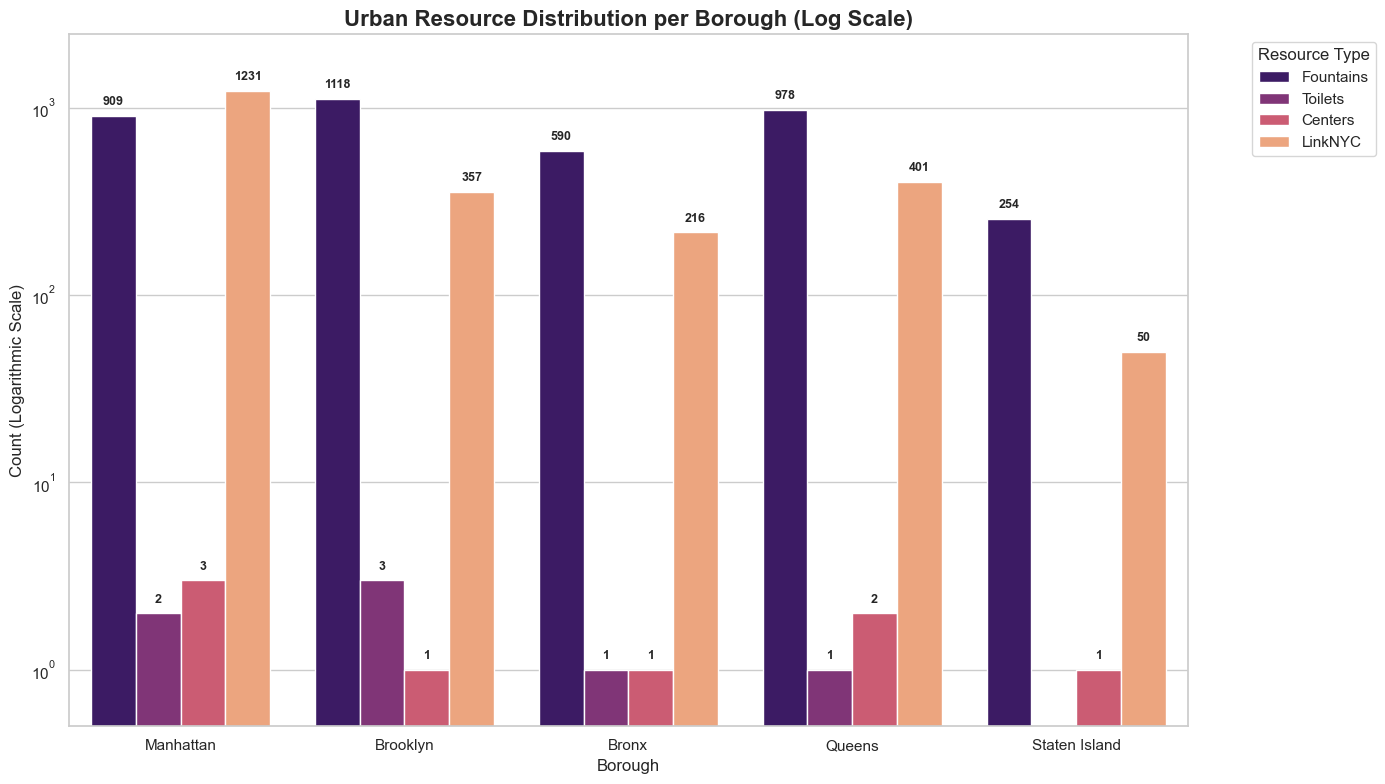

In [14]:
# Standardizing index names for the summary plot
res_summary = pd.DataFrame({
    'Fountains': fountains['borough'].value_counts(),
    'Toilets': toilets['boro_name'].value_counts(),
    'Centers': centers['borough'].value_counts(),
    'LinkNYC': link['boro'].value_counts()
}).fillna(0)

# Ensure the index only contains the 5 boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Bronx', 'Queens', 'Staten Island']
res_summary = res_summary.reindex(boroughs).fillna(0)

# Melt for better plotting with Seaborn
plot_df = res_summary.reset_index().melt(id_vars='index', var_name='Resource', value_name='Count')
plot_df.rename(columns={'index': 'Borough'}, inplace=True)

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=plot_df, x='Borough', y='Count', hue='Resource', palette='magma')

# 1. Use Log Scale to handle the huge disparity (thousands vs single digits)
plt.yscale('log')
plt.ylim(0.5, plot_df['Count'].max() * 2) # Start at 0.5 so '1' is visible

# 2. Add exact count labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontsize=9, fontweight='bold')

plt.title('Urban Resource Distribution per Borough (Log Scale)', fontsize=16, fontweight='bold')
plt.ylabel('Count (Logarithmic Scale)', fontsize=12)
plt.xlabel('Borough', fontsize=12)
plt.legend(title='Resource Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
import folium
from folium import plugins
from IPython.display import display

# 1. Custom CSS Cluster Logic
# Function to create different looking clusters for different types
def get_custom_cluster(color, glow_color, shape="50%"):
    return f"""
    function(cluster) {{
        return new L.DivIcon({{ 
            html: '<div style="background-color: {color}; color: white; border-radius: {shape}; width: 32px; height: 32px; display: flex; justify-content: center; align-items: center; border: 2px solid {glow_color}; box-shadow: 0 0 12px {glow_color}; font-weight: bold;">' + cluster.getChildCount() + '</div>', 
            className: 'marker-cluster', iconSize: new L.Point(40, 40) 
        }});
    }}
    """

# 2. INITIALIZE MAP
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB dark_matter')

# 3. CRIME HOTSPOTS (Unchanged)
weights = crime.groupby(['latitude', 'longitude']).size().reset_index(name='count')
hotspots = weights[weights['count'] > weights['count'].quantile(0.95)]
plugins.HeatMap(
    hotspots.values.tolist(), 
    name="Crime Risk Hotspots", radius=10, blur=8, min_opacity=0.4,
    gradient={0.4: 'orange', 0.7: 'red', 1: 'darkred'} 
).add_to(m)

# 4. RESOURCES (With distinct visual styles)

# WATER: Cyan Circles + Blue Round Glow
fountain_cluster = plugins.MarkerCluster(
    name="Drinking Fountains",
    icon_create_function=get_custom_cluster("rgba(0, 191, 255, 0.7)", "cyan")
).add_to(m)

for _, row in fountains.dropna(subset=['latitude', 'longitude']).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']], 
        radius=2.5, color='cyan', fill=True, fill_opacity=0.8,
        popup="Fountain"
    ).add_to(fountain_cluster)

# DIGITAL: Black/White Icons + Yellow Square Glow
link_cluster = plugins.MarkerCluster(
    name="LinkNYC Wifi Hubs",
    icon_create_function=get_custom_cluster("rgba(30, 30, 30, 0.9)", "gold", shape="5px") # Square-ish for Tech
).add_to(m)

for _, row in link.dropna(subset=['latitude', 'longitude']).iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']], 
        icon=folium.Icon(color='black', icon='wifi', prefix='fa', icon_color='white'),
        popup="LinkNYC Hub"
    ).add_to(link_cluster)

# 5. OTHER RESOURCES (Small Datasets)
centers_layer = folium.FeatureGroup(name="Drop-in Centers")
for _, row in centers.dropna(subset=['latitude', 'longitude']).iterrows():
    folium.Marker(location=[row['latitude'], row['longitude']], icon=folium.Icon(color='green', icon='home', prefix='fa')).add_to(centers_layer)
centers_layer.add_to(m)

toilets_layer = folium.FeatureGroup(name="Public Toilets")
for _, row in toilets.dropna(subset=['latitude', 'longitude']).iterrows():
    folium.Marker(location=[row['latitude'], row['longitude']], icon=folium.Icon(color='orange', icon='restroom', prefix='fa')).add_to(toilets_layer)
toilets_layer.add_to(m)

# 6. SAVE & VIEW
folium.LayerControl(collapsed=False).add_to(m)
m.save('final_survival_map.html')
display(m)


NameError: name 'crime' is not defined

## Basic stats — quick aggregates and checks

We load (or compute) a borough-level resource summary and inspect basic grid and crime statistics. The cell below prefers the precomputed `resource_summary.csv` when available; otherwise it computes a quick fallback by counting borough mentions in each resource CSV.

In [ ]:
# Load resource summary if present, otherwise compute a quick fallback
resource_summary_path = ASSETS / 'resource_summary.csv'
if resource_summary_path.exists():
    resource_summary = pd.read_csv(resource_summary_path)
    print('Loaded existing resource_summary.csv')
else:
    print('resource_summary.csv not found — computing fallback counts (approx.)')
    resource_summary = pd.DataFrame({'Borough':['Manhattan','Brooklyn','Bronx','Queens','Staten Island']})
    def count_boroughs(df):
        if df.empty: return [0]*5
        # try common borough-like fields
        for candidate in ('borough','boro','boro_name','BORO_NM','Borough'):
            if candidate in df.columns:
                s = df[candidate].astype(str).fillna('')
                return [
                    s.str.contains('Manhattan', case=False).sum(),
                    s.str.contains('Brooklyn', case=False).sum(),
                    s.str.contains('Bronx', case=False).sum(),
                    s.str.contains('Queens', case=False).sum(),
                    (s.str.contains('Staten', case=False) | s.str.contains('Richmond', case=False)).sum()
                ]
        return [0]*5
    resource_summary['Fountains'] = count_boroughs(fountains)
    resource_summary['Toilets'] = count_boroughs(toilets)
    resource_summary['Centers'] = count_boroughs(centers)
    resource_summary['LinkNYC'] = count_boroughs(linknyc)

resource_summary

In [ ]:
# Grid and crime quick checks
if not grid.empty:
    print('Grid points:', len(grid))
    display(grid.describe().T)
else:
    print('Grid CSV missing or empty')

if not crime.empty:
    for c in ('latitude','longitude'):
        if c in crime.columns:
            crime[c] = pd.to_numeric(crime[c], errors='coerce')
    print('Crime rows:', len(crime))
    display(crime[['latitude','longitude']].dropna().head())
else:
    print('Crime CSV missing or empty')

In [ ]:
# Plot: Borough resource counts (grouped bar chart, log y-axis)
if not resource_summary.empty:
    dfm = resource_summary.melt(id_vars='Borough', var_name='Resource', value_name='Count')
    fig = px.bar(dfm, x='Borough', y='Count', color='Resource', barmode='group', title='Resource counts by Borough')
    fig.update_layout(yaxis_type='log', template='plotly_dark', legend=dict(orientation='h', y=-0.2))
    fig.show()
else:
    print('No resource summary available to plot')

## Data cleaning and preprocessing choices

- We used the cleaned CSVs in `data/processed/` whenever available. Cleaning steps performed previously include trimming whitespace, coercing lat/lon to numeric, and dropping rows with missing coordinates.
- For scoring we snap each point to the nearest grid cell using median grid step sizes — a computationally cheap approximation to more expensive spatial joins.
- Resource weights are heuristic: fountains=1, toilets=5, centers=8, shelters=10. These reflect relative utility in day-to-day survival but can be tuned.
- Crime filtering: where a date column exists we focus on recent incidents (example cutoff: 2014+).

## EDA takeaways (short)

- Resource distribution is skewed: LinkNYC kiosks and fountains concentrate in Manhattan and parts of Brooklyn.
- Crime points cluster into hotspots; combining a crime heatmap with resource points helps identify places where resources and risk coincide.
- The Survival Score (normalized resources and inverted crime norm) offers a clear relative ranking but simplifies many lived-experience factors (hours, service quality).

## Data Analysis — what we learned

Proximity to multiple resource types correlates with higher Survival Scores. Areas with low resource density and higher crime exposure receive lower scores. No supervised ML model was necessary for the final deliverable — we used engineered features and normalization to produce a comparative index for visualization and storytelling.

## Genre and Visual Narrative choices

**Genre**: Exploratory + Expository — a guided narrative with interactive exploration.

**Visual Narrative — tools used**:
- Representation: Heatmap (folium) for crime hotspots, point layers for resources, and grouped bar charts (Plotly) for borough comparisons.
- Annotation: map popups, callouts in the narrative, and axis/legend text.
- Interaction: map layer toggles, zoom/pan, and hover tooltips in charts.

## Visualizations — why these were chosen

- A map is essential to convey geographic patterns.
- Bar charts summarize cross-borough differences compactly and work well with log scales to handle range differences.
- Short top/bottom lists are useful for highlighting extremes and supporting narrative takeaways.

## Discussion — critical reflection

**What went well**:
- Combining map and chart delivered a clear story and allowed both guided and exploratory consumption.

**What is missing / could be improved**:
- Tune weights with stakeholder input or use optimization methods.
- Replace grid-snapping with network-distance accessibility (OSM routing) for realism.
- Include service hours and capacity where available.

**Next steps**:
- Add an interactive weighting UI so readers can test different assumptions.
- Consider a small validation study comparing the score to lived experience surveys.

## Contributions

- Christoffer Frost — front-end site composition, interactive embedding, CSS/UX work, and notebook/documentation.
- Lorenzo Gelao — data collection, cleaning scripts, scoring implementation, and folium map generation.

Both members collaborated on interpretation, visualization choices, and narrative structure.

## References

- Segal, M., & Heer, J. (2010). Narrative visualization: Telling stories with data. IEEE Transactions on Visualization and Computer Graphics.
- NYC Open Data portals for each dataset (linked in the project README).

---
Run the code cells above to reproduce the basic figures and checks. If you want, I can now execute the notebook and save output cells (figures) or export the notebook as a static HTML under `website/notebooks/` for direct site linking.